In [1]:
from skimage.io import imread
import numpy as np
from scipy.io import loadmat
import scipy.sparse.linalg
from matplotlib import pyplot as plt
import time
import os


In [2]:
from google.colab import drive
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/Uni/ImageProcessing')
rootfolder = 'Colab Students - Assignments/data'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


IRLS Algorithm
--------------
Define the problem parameters


In [3]:
A = np.array([[1, 3], [3, 1]]) # low dimensions to plot it, you can test larger sizes
b = np.array([-1, 2])

lmbda = 0.5


The function to be minimized is $\frac{1}{2}\|Ax-b\|_2^2 + \lambda \|x\|_1$

In [4]:
f = lambda x: 0.5 * np.sum((A @ x - b) ** 2) + lmbda * np.sum(np.abs(x))

# derivative of f from matrix calculus
df = lambda x: A.T @ (A @ x) - A.T @ b


Plot the function

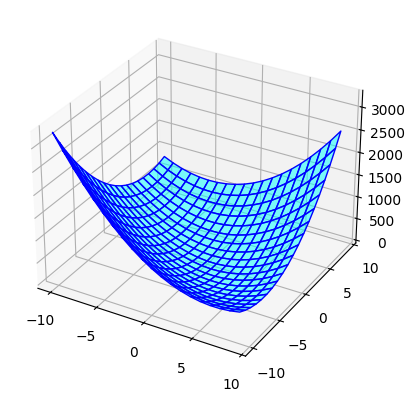

In [5]:
# this function has been prepared only for the visualization sake, no need to go through this but it renders some nice
# graphics :)
F = lambda r1, r2: (r1 * A[0, 0] + r2 * A[0, 1] - b[0]) ** 2 + (r1 * A[1, 0] + r2 * A[1,1] - b[1]) ** 2 + lmbda * (np.abs(r1) + np.abs(r2))
xx, yy = np.meshgrid(np.arange(-10, 10, 1), np.arange(-10, 10, 1))

fig = plt.figure()
ax = plt.axes(projection='3d')
ax.plot_surface(xx, yy, F(xx, yy), edgecolor=[0, 0, 1], alpha=0.5, facecolor=[0, 1, 1])

Set the parameters

In [6]:
MAX_ITER = 1e3
TOL_DIST_X = 1e-10

Initialization: test different inizializations, the function is convex, you always converge to the same solution

In [7]:
x0 = np.array([5, -10])

# initialization
all_x = [x0]
distanceX = 1e10  # stopping criteria
cnt = 0
delta = 1e-6

Main loop

In [8]:
while cnt < MAX_ITER and distanceX > TOL_DIST_X:
    x = all_x[-1]

    # compute the weight matrix
    W = np.diag(1/(np.abs(x)+ delta))

    # solve the weighted regularized LS system
    x_current = scipy.sparse.linalg.cg(A.T @ A + lmbda * W , A.T @ b)[0]

    distanceX = np.linalg.norm(x_current - x)

    # store the estimate
    # update all_x
    all_x.append(x_current)

    cnt = cnt + 1

Plot all the estimates

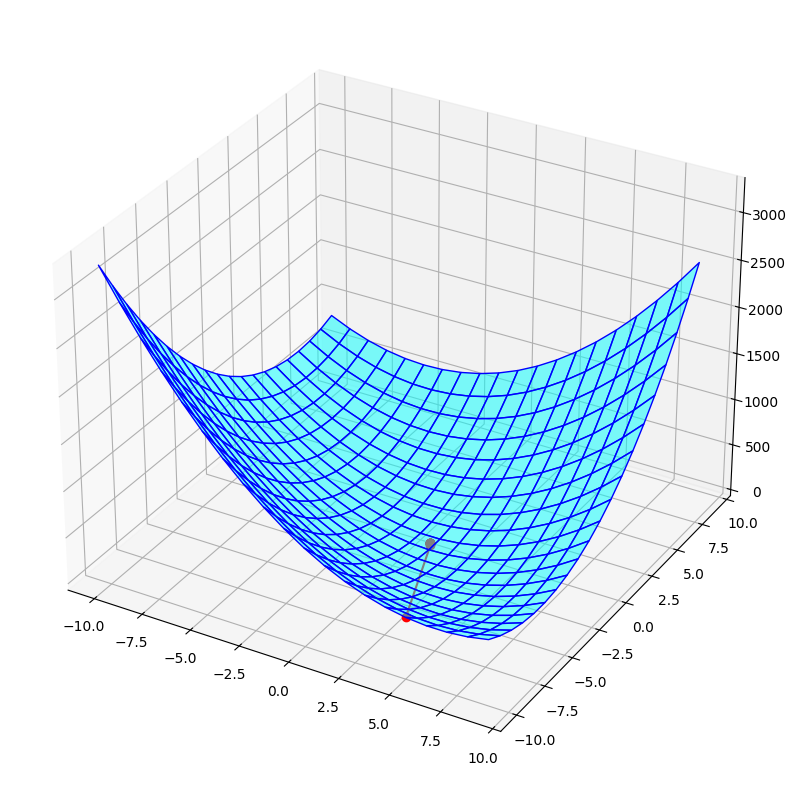

In [9]:
# plot the new estimate
xxplot = [x[0] for x in all_x]
yyplot = [x[1] for x in all_x]
zzplot = F(np.array(xxplot), np.array(yyplot))

fig = plt.figure(figsize=(10,10))
ax = plt.axes(projection='3d')
ax.plot_surface(xx, yy, F(xx, yy), edgecolor=[0, 0, 1], alpha=0.5, facecolor=[0, 1, 1])
ax.plot3D(xxplot, yyplot, zzplot, 'r-o')

In [10]:
print(f'nr of iteration of IRLS (before stopping criteria met): {cnt}\n')
print(f'Solution of IRLS: [{x_current[0]:.4f}, {x_current[1]:.4f}]\n')
print(f'Value of the functional: {f(x_current):.4f}\n')


nr of iteration of IRLS (before stopping criteria met): 14

Solution of IRLS: [0.7500, -0.5000]

Value of the functional: 0.6875



MOD dictionary learning
-----------------------
Useful function for plot the 2D DCT dictionary

In [11]:
def get_dictionary_img(D):
    M, N = D.shape
    p = int(round(np.sqrt(M)))
    nnn = int(np.ceil(np.sqrt(N)))
    bound = 2
    img = np.ones((nnn*p+bound*(nnn-1), nnn*p+bound*(nnn-1)))
    for i in range(N):
        m = np.mod(i, nnn)
        n = int((i-m)/nnn)
        m = m * p + bound * m
        n = n * p + bound * n
        atom = D[:, i].reshape((p, p))
        if atom.min() < atom.max():
            atom = (atom - atom.min()) / (atom.max() - atom.min())
        img[m: m + p, n: n + p] = atom

    return img

Define a function to perform the sparse coding using your favorite algorithm (IRLS, FISTA or ISTA)

In [12]:
def IRLS(s, D, lmbda, x0=None):
    max_iter = 50
    tol = 1e-5
    delta = 1e-6

    if x0 is None:
        x0 = np.zeros(D.shape[1])

    x = x0
    DtD = D.T @ D
    Dts = D.T @ s

    for _ in range(max_iter):
        W = np.diag(1.0 / np.maximum(np.abs(x), delta))
        x_next = np.linalg.solve(DtD + lmbda * W, Dts)

        if np.linalg.norm(x_next - x) < tol:
            break

        x = x_next

    return x

In [13]:
def FISTA(s, D, lmbda, x0_initial=None):
  # Use the passed x0 if available, otherwise use a default
  if x0_initial is None:
    x = np.zeros(D.shape[1]) # D.shape[1] is N, the number of dictionary atoms
  else:
    x = x0_initial.copy()

  y = x.copy()

  gamma = 1.0

  # Calculate Lipschitz constant
  L = np.linalg.norm(D, ord=2) ** 2
  if L == 0:
      alpha = 1.0
  else:
      alpha = 1.0 / L

  all_x = [x]
  distanceX = 1e10
  cnt = 0

  while cnt < MAX_ITER and distanceX > TOL_DIST_X:
    x_prev_k = x.copy()

    # Calculate gradient of f(x)
    gradient_f_at_y = D.T @ (D @ y - s)

    # compute the argument of the proximal operator: y_k - alpha * grad_f(y_k)
    argument_prox = y - alpha * gradient_f_at_y

    # perform soft thresholding to get x_k_plus_1
    x_current = np.sign(argument_prox) * np.maximum(0, np.abs(argument_prox) - alpha * lmbda)

    # update gamma_k_plus_1
    gamma_next = (1 + np.sqrt(1 + 4 * gamma ** 2)) / 2

    # update y_k_plus_1
    y = x_current + ( (gamma - 1) / gamma_next ) * (x_current - x_prev_k)

    # compute the stopping criteria
    distanceX = np.linalg.norm(x_current - x_prev_k)

    # Update x and gamma for next iteration
    x = x_current
    gamma = gamma_next

    # store the estimate
    all_x.append(x.copy())

    cnt = cnt + 1

  return x

Load the image and rescale it in [0,1]

In [14]:
img = imread(f'{rootfolder}/barbara.png') / 255
imsz = img.shape

Set the parameters

In [15]:
# patch size
p = 8

# number of elements in the patchfrom skimage.io import imread
M = p ** 2

# number of columns in the dictionary
N = 96

# extract the random patches from the noisy image
npatch = 100

# only few MOD iterations are needed for a good dictionary
max_iter = 10

lmbda = 0.1

Extract $npatch$ random patches from the image


In [16]:
S = np.zeros((M, npatch))

for i in range(npatch):
    r = np.random.randint(0, imsz[0] - p)
    c = np.random.randint(0, imsz[1] - p)
    S[:, i] = img[r:r+p, c:c+p].flatten()

Initialize the dictionary randomly and the normalize the columns

In [17]:
D = np.random.randn(M, N)
D = D / np.linalg.norm(D, axis=0)

Initialize a matrix for the coefficients of all the patches

In [18]:
X = np.zeros((N, npatch))

Main loop

In [19]:
for iter in range(max_iter):
    for n in range(npatch):
        s = S[:, n]
        X[:, n] = IRLS(s, D, lmbda)

    # MOD update
    D = S @ X.T @ np.linalg.inv(X @ X.T + 1e-8 * np.eye(N))

    # normalize columns
    D = D / np.linalg.norm(D, axis=0)

Show the dictionary

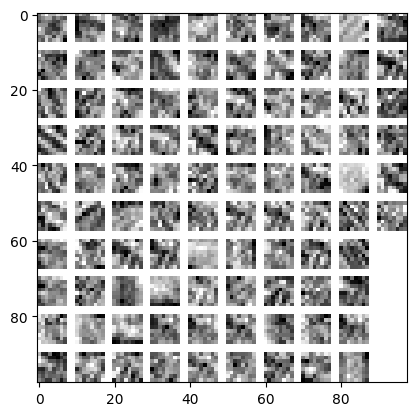

In [20]:
img_dict = get_dictionary_img(D)
plt.figure()
plt.imshow(img_dict, cmap='gray')


Denoising via $\ell^1$ sparse coding (you can use either the dictionary learned by KSVD or MOD)
------------------------------------
Set the noise level and add the noise to the original image

In [21]:
sigma_noise = 20/255
noisy_img = img + np.random.normal(size=imsz) * sigma_noise


Compute the psnr of the noisy input

In [22]:
psnr_noisy = 10 * np.log10(1.0 / np.mean((img - noisy_img) ** 2))

Text(0.5, 1.0, 'Noisy image, PSNR = 22.09')

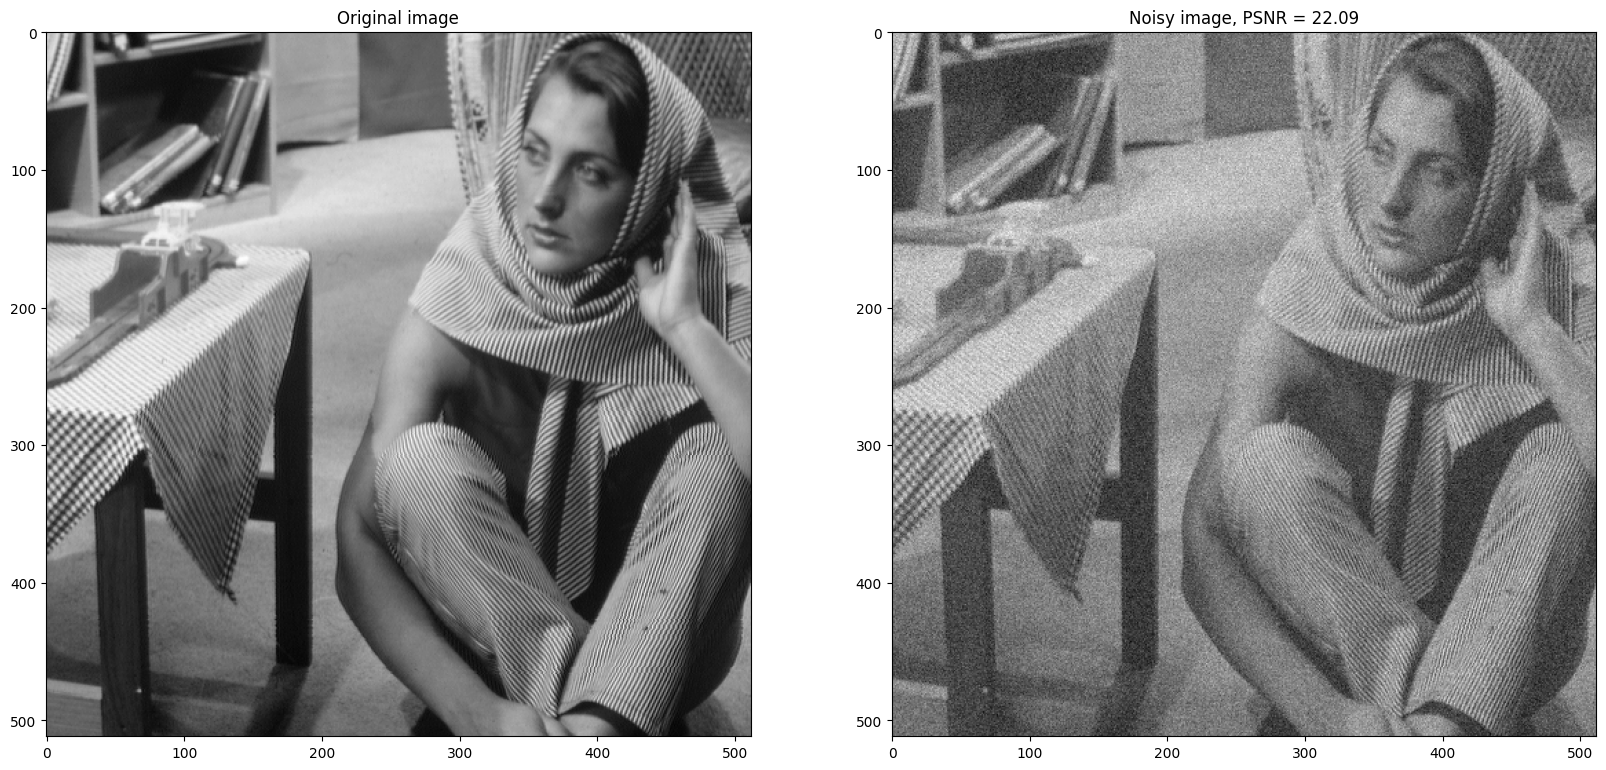

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(20, 10))
ax[0].imshow(img, cmap='gray')
ax[0].set_title('Original image')

ax[1].imshow(noisy_img, cmap='gray')
ax[1].set_title(f'Noisy image, PSNR = {psnr_noisy:.2f}')

Load a pretrained dictionary $D$

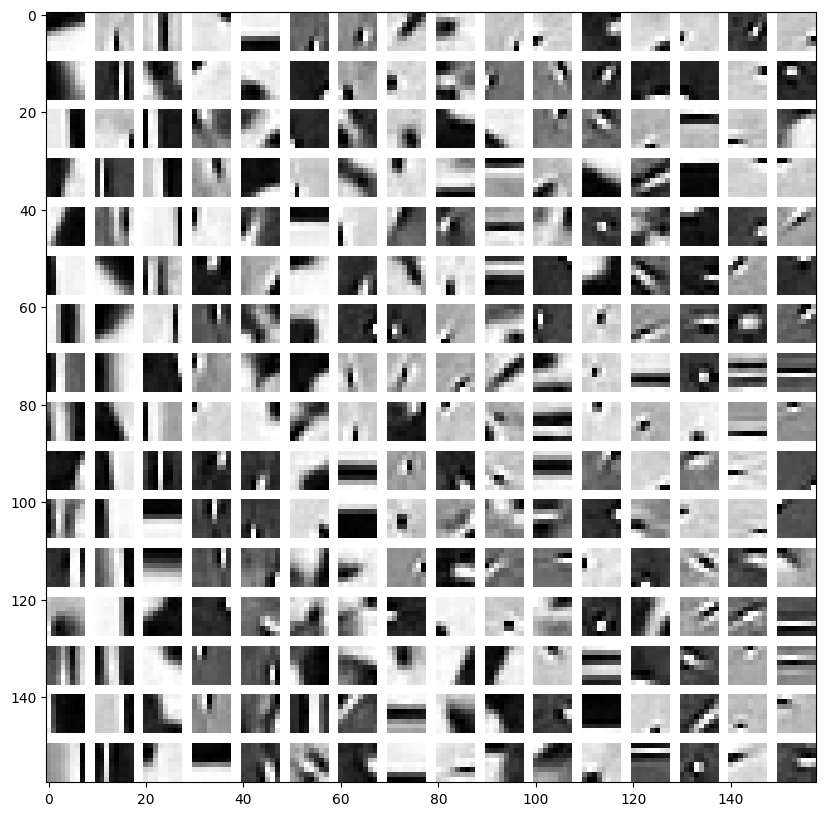

In [24]:
D = loadmat(f'{rootfolder}/dict_nat_img.mat')['D']

# show the dictionary
D_img = get_dictionary_img(D)
plt.figure(figsize=(10,10))
plt.imshow(D_img, cmap='gray')


In [25]:
# initialize the estimated image
img_hat_FISTA = np.zeros_like(img)

# initialize the weight matrix
weights_FISTA = np.zeros_like(img)

# set the threshold
tau = 2.2
lmbda = tau * sigma_noise

# define the step (=p for non overlapping paches)
STEP = 4 # STEP = 1 might be very time consuming, start with larger STEP

Operate patchwise, use FISTA to perform the Sparse Coding step.

In [27]:
for i in range(0, imsz[0] - p + 1, STEP):
    for j in range(0, imsz[1] - p + 1, STEP):
        s = noisy_img[i:i+p, j:j+p].flatten()

        m = np.mean(s)
        s_zm = s - m

        x = FISTA(s_zm, D, lmbda)

        s_hat = D @ x + m

        img_hat_FISTA[i:i+p, j:j+p] += s_hat.reshape(p, p)
        weights_FISTA[i:i+p, j:j+p] += 1.0

Normalize the estimated image with the computed weights

In [28]:
img_hat_FISTA = img_hat_FISTA / (weights_FISTA + 1e-8)

Compute the psnr of the estimated image

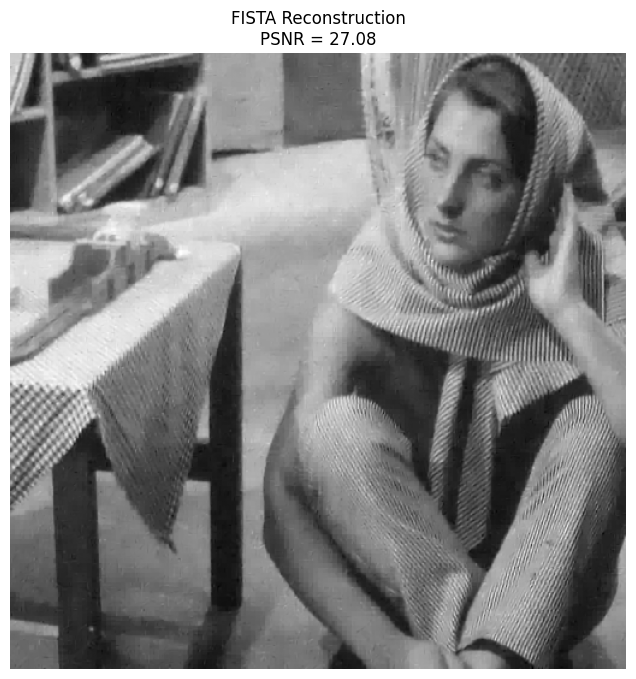

In [29]:
# Compute PSNR
psnr_hat_FISTA = 10 * np.log10(1 / np.mean((img - img_hat_FISTA) ** 2))

plt.figure(figsize=(8, 8))
plt.imshow(img_hat_FISTA, cmap='gray')
plt.title(f'FISTA Reconstruction\nPSNR = {psnr_hat_FISTA:.2f}')
plt.axis('off')
plt.show()

Repeat the same process, but this time replace FISTA with IRLS and compare the denoised images.

In [30]:
# initialize the estimated image
img_hat_IRLS = np.zeros_like(img)

# initialize the weight matrix
weights_IRLS = np.zeros_like(img)

In [31]:
for i in range(0, imsz[0] - p + 1, STEP):
    for j in range(0, imsz[1] - p + 1, STEP):
        s = noisy_img[i:i+p, j:j+p].flatten()

        m = np.mean(s)
        s_zm = s - m

        x = IRLS(s_zm, D, lmbda)

        s_hat = D @ x + m

        img_hat_IRLS[i:i+p, j:j+p] += s_hat.reshape(p, p)
        weights_IRLS[i:i+p, j:j+p] += 1.0

KeyboardInterrupt: 

In [ ]:
img_hat_IRLS = img_hat_IRLS / (weights_IRLS + 1e-8)

In [ ]:
# Final Comparison
psnr_hat_IRLS = 10 * np.log10(1 / np.mean((img - img_hat_IRLS) ** 2))

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes[0].imshow(img_hat_FISTA, cmap='gray')
axes[0].set_title(f'FISTA Result (PSNR: {psnr_hat_FISTA:.2f})')
axes[1].imshow(img_hat_IRLS, cmap='gray')
axes[1].set_title(f'IRLS Result (PSNR: {psnr_hat_IRLS:.2f})')
for ax in axes: ax.axis('off')
plt.show()